<a href="https://colab.research.google.com/github/kartikigaikwad/Amazon-Clone/blob/main/Kartiki_capstone_python_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project II

In [1]:
# ----------------------------------------------------
# 📌 Colab Cell 1 — Install & Imports (Improved Version)
# ----------------------------------------------------

# Install missing packages only if needed
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.dates import DateFormatter
    import seaborn as sns
    from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
    from sklearn.linear_model import Ridge, LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import joblib
    import xgboost as xgb
    import statsmodels.api as sm
    from statsmodels.tsa.seasonal import seasonal_decompose
    import warnings
    import os
    from datetime import datetime

except Exception as e:
    print("Installing missing dependencies...")
    !pip install -q xgboost joblib statsmodels seaborn

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.dates import DateFormatter
    import seaborn as sns
    from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
    from sklearn.linear_model import Ridge, LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import joblib
    import xgboost as xgb
    import statsmodels.api as sm
    from statsmodels.tsa.seasonal import seasonal_decompose
    import warnings
    import os
    from datetime import datetime

# Plot style settings
%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")

print("All libraries successfully imported.")


All libraries successfully imported.


In [2]:
# ----------------------------------------------------
# 📌 Colab Cell 2 — Config & Utility Functions (Improved)
# ----------------------------------------------------

# File paths (update if your files are placed elsewhere)
DAILY_PATH = '/content/salesdaily.csv'
WEEKLY_PATH = '/content/salesweekly.csv'
HOURLY_PATH = '/content/saleshourly.csv'
MONTHLY_PATH = '/content/salesmonthly.csv'

# ---------------- Utility Functions ----------------

def quick_info(df, name='df'):
    """
    Print shape, columns, missing values, dtypes, and head preview.
    """
    print(f"\n{name} shape: {df.shape}")
    print('Columns:', df.columns.tolist())
    print('\nData Types:')
    print(df.dtypes)
    print('\nMissing values:')
    print(df.isnull().sum())
    print('\nBasic Statistics:')
    display(df.describe())
    print('\nPreview:')
    display(df.head())


def save_fig(fig, fname, dpi=150):
    """
    Save a matplotlib figure with tight layout.
    Creates directories if they do not exist.
    """
    folder = os.path.dirname(fname)
    if folder and not os.path.exists(folder):
        os.makedirs(folder)
    fig.tight_layout()
    fig.savefig(fname, dpi=dpi)
    print(f'Saved {fname}')


In [5]:
from pathlib import Path

# ----------------- Data Ingestion & Initial Inspection (Updated for ATC) -----------------

paths = {
    'daily': Path(DAILY_PATH),
    'weekly': Path(WEEKLY_PATH),
    'hourly': Path(HOURLY_PATH),
    'monthly': Path(MONTHLY_PATH)
}

loaded = {}
for label, p in paths.items():
    if p.exists():
        try:
            df = pd.read_csv(p)
            loaded[label] = df
            print(f"Loaded {label}: {p} -> shape {df.shape}")
        except Exception as e:
            print(f"Failed to load {p}: {e}")
    else:
        print(f"Not found: {p}")

# Choose primary dataset: weekly > monthly > daily > hourly
primary = None
for option in ['weekly', 'monthly', 'daily', 'hourly']:
    if option in loaded:
        primary = option
        break

if primary is None:
    raise FileNotFoundError("No data files found.")

print(f"\nPrimary dataset chosen: {primary}")

# Rename 'datum' → 'date' if exists, otherwise keep original
df = loaded[primary].copy()
if 'datum' in df.columns:
    df = df.rename(columns={'datum': 'date'})
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').reset_index(drop=True)

# Detect sales columns (all numeric except 'date')
SALES_COLS = df.select_dtypes(include=np.number).columns.tolist()
print("Detected numeric sales columns (ATC codes):", SALES_COLS)

# Treat all numeric columns as ATC codes (since dataset has no separate category column)
ATC_COLS = SALES_COLS
QUANTITY_COLS = SALES_COLS

print("ATC category columns (derived from numeric columns):", ATC_COLS)
print("Quantity columns:", QUANTITY_COLS)

# Quick overview
quick_info(df, name=f"primary ({primary})")

# Summary statistics for sales columns
print("\nTotal sales per column:")
display(df[SALES_COLS].sum())

print("\nNumber of non-zero sales per column:")
display((df[SALES_COLS] > 0).sum())

# Keep for later processing
PRIMARY_DF = df


Loaded daily: /content/salesdaily.csv -> shape (2106, 13)
Loaded weekly: /content/salesweekly.csv -> shape (302, 9)
Loaded hourly: /content/saleshourly.csv -> shape (50532, 13)
Loaded monthly: /content/salesmonthly.csv -> shape (70, 9)

Primary dataset chosen: weekly
Detected numeric sales columns (ATC codes): ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
ATC category columns (derived from numeric columns): ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
Quantity columns: ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

primary (weekly) shape: (302, 9)
Columns: ['date', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

Data Types:
date     datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
dtype: object

Missing values:
date     0
M01AB    0
M01AE    0
N02BA

,date,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,302,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,2016-11-23 12:00:00,35.102441,27.167611,27.060295,208.627161,61.740853,4.138935,38.439811,20.224561
min,2014-01-05 00:00:00,7.670000,6.237000,3.500000,86.250000,18.000000,0.000000,2.000000,1.000000
25%,2015-06-15 18:00:00,29.387500,22.387500,21.300000,149.300000,47.000000,2.000000,21.000000,11.475000
50%,2016-11-23 12:00:00,34.565000,26.789500,26.500000,198.300000,57.000000,3.979167,35.000000,17.500000
75%,2018-05-04 06:00:00,40.175000,31.046500,32.475000,252.471500,71.000000,6.000000,51.000000,26.000000
max,2019-10-13 00:00:00,65.330000,53.571000,60.125000,546.899000,154.000000,17.000000,131.000000,65.000000
std,NaN,8.617106,7.043491,8.086458,76.069221,22.436970,3.129265,22.900873,11.381464



Preview:


,date,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0



Total sales per column:


,0
M01AB,10600.937083
M01AE,8204.618646
N02BA,8172.209000
N02BE,63005.402708
N05B,18645.737500
N05C,1249.958333
R03,11608.822917
R06,6107.817500



Number of non-zero sales per column:


,0
M01AB,302
M01AE,302
N02BA,302
N02BE,302
N05B,302
N05C,266
R03,302
R06,302


In [6]:
# ----------------- Data Cleaning & Formatting -----------------

df = PRIMARY_DF.copy()

# 1) Drop duplicates and rows with null dates
before = df.shape[0]
df = df.drop_duplicates()
df = df[~df['date'].isnull()].reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} duplicate/null rows")

# 2) Detect sales columns (all numeric except date)
SALES_COLS = df.select_dtypes(include=np.number).columns.tolist()
print('Sales columns:', SALES_COLS)

# 3) Create a total_sales aggregate
df['total_sales'] = df[SALES_COLS].sum(axis=1)

# 4) Normalize numeric columns (if object type)
for c in SALES_COLS:
    if df[c].dtype == object:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# Optional: remove negative sales
df[SALES_COLS] = df[SALES_COLS].clip(lower=0)

# 5) Set date as index
df = df.set_index('date').sort_index()

# 6) Filter timeframe
START = '2014-01-01'
END = '2018-12-31'
try:
    df = df.loc[(df.index >= START) & (df.index <= END)]
    print(f"Filtered timeframe to {START} - {END}: new shape {df.shape}")
except Exception:
    print('Could not filter by timeframe. Proceeding with full range.')

# 7) Sanity check for total_sales
print("\nTotal sales summary:")
display(df['total_sales'].describe())

# Keep cleaned df
CLEANED_DF = df.copy()
quick_info(CLEANED_DF, name='CLEANED_DF')


Dropped 0 duplicate/null rows
Sales columns: ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
Filtered timeframe to 2014-01-01 - 2018-12-31: new shape (261, 9)

Total sales summary:


,total_sales
count,261.000000
mean,423.092676
std,95.268003
min,236.078000
25%,349.668000
50%,410.075000
75%,480.173667
max,790.837167



CLEANED_DF shape: (261, 9)
Columns: ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'total_sales']

Data Types:
M01AB          float64
M01AE          float64
N02BA          float64
N02BE          float64
N05B           float64
N05C           float64
R03            float64
R06            float64
total_sales    float64
dtype: object

Missing values:
M01AB          0
M01AE          0
N02BA          0
N02BE          0
N05B           0
N05C           0
R03            0
R06            0
total_sales    0
dtype: int64

Basic Statistics:


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,total_sales
count,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000
mean,34.772671,27.262232,27.920341,210.645256,62.184435,4.038155,36.996608,19.272979,423.092676
std,8.605685,6.304964,8.098704,74.109019,23.563925,3.189484,21.339719,10.842555,95.268003
min,14.000000,7.710000,10.150000,92.850000,18.000000,0.000000,2.000000,3.000000,236.078000
25%,28.680000,22.859000,22.400000,152.100000,45.000000,2.000000,21.000000,11.000000,349.668000
50%,33.830000,27.098000,27.750000,203.624000,57.000000,3.000000,33.000000,17.000000,410.075000
75%,39.980000,31.083000,33.541667,253.900000,72.000000,5.416667,50.000000,24.800000,480.173667
max,65.330000,48.752000,60.125000,546.899000,154.000000,17.000000,116.000000,65.000000,790.837167



Preview:


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,total_sales
date,,,,,,,,,
2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0,312.92
2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2,391.81
2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0,450.31
2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0,398.47
2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0,371.95


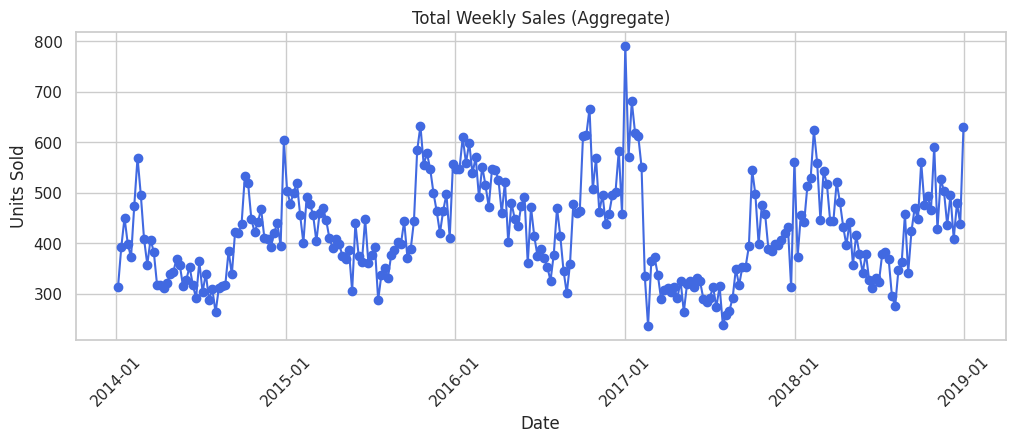

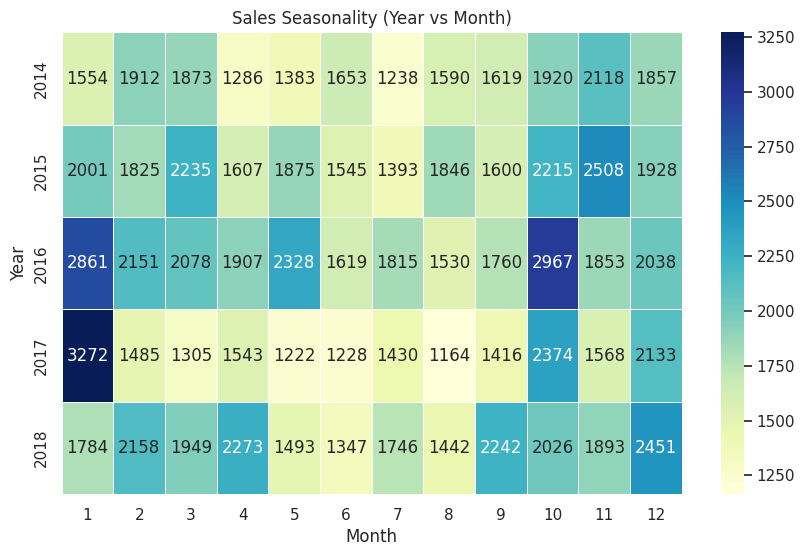

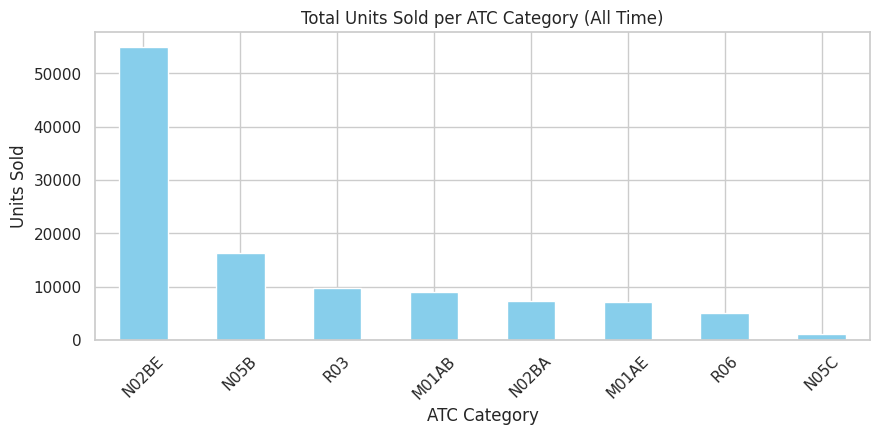

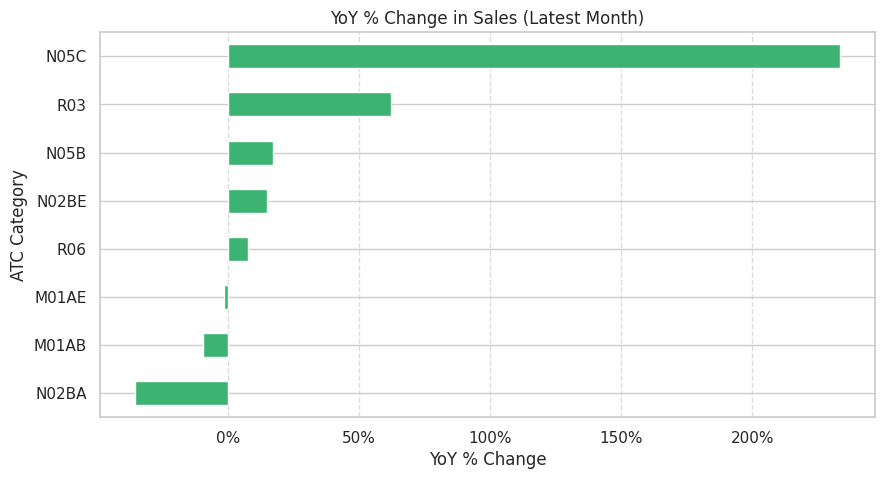


YoY % Change (Latest Month) shape: (8, 2)
Columns: ['category', 'pct_yoy']

Data Types:
category     object
pct_yoy     float64
dtype: object

Missing values:
category    0
pct_yoy     0
dtype: int64

Basic Statistics:


,pct_yoy
count,8.000000
mean,36.121053
std,84.341778
min,-35.265520
25%,-3.584032
50%,11.292448
75%,28.467776
max,233.333333



Preview:


,category,pct_yoy
0,M01AB,-9.525678
1,M01AE,-1.603483
2,N02BA,-35.265520
3,N02BE,14.970682
4,N05B,17.213115


In [8]:
# ----------------- Exploratory Data Analysis (EDA) — Polished -----------------

import matplotlib.ticker as mtick

# 1) Total weekly sales
resample_freq = 'W'
total_series = CLEANED_DF['total_sales'].resample(resample_freq).sum()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(total_series.index, total_series.values, marker='o', color='royalblue')
ax.set_title('Total Weekly Sales (Aggregate)')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# 2) Seasonality heatmap (month vs year)
sales_monthly = CLEANED_DF['total_sales'].resample('M').sum().to_frame('sales')
sales_monthly['year'] = sales_monthly.index.year
sales_monthly['month'] = sales_monthly.index.month

pivot = sales_monthly.pivot_table(index='year', columns='month', values='sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', linewidths=.5, cmap='YlGnBu', ax=ax)
ax.set_title('Sales Seasonality (Year vs Month)')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.show()


# 3) Total sales per ATC category
cat_totals = CLEANED_DF[SALES_COLS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,4))
cat_totals.plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Total Units Sold per ATC Category (All Time)')
ax.set_xlabel('ATC Category')
ax.set_ylabel('Units Sold')
plt.xticks(rotation=45)
plt.show()


# 4) YoY % change per category (latest month)
pivot_monthly = CLEANED_DF[SALES_COLS].resample('M').sum()
pct_yoy = pivot_monthly.pct_change(periods=12)
latest_pct_yoy = pct_yoy.tail(1).T
latest_pct_yoy.columns = ['pct_yoy']
latest_pct_yoy['pct_yoy'] = latest_pct_yoy['pct_yoy'] * 100  # convert to %

# Horizontal bar chart for clear visualization
fig, ax = plt.subplots(figsize=(10,5))
latest_pct_yoy.sort_values('pct_yoy')['pct_yoy'].plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('YoY % Change in Sales (Latest Month)')
ax.set_xlabel('YoY % Change')
ax.set_ylabel('ATC Category')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Quick info table
quick_info(latest_pct_yoy.reset_index().rename(columns={'index':'category'}), name='YoY % Change (Latest Month)')


In [9]:
# ----------------- Feature Engineering (Phase 4) — All Categories -----------------

# Reusable function to create time features for a single pd.Series (weekly indexed)
def make_time_features(series: pd.Series, lags=[1,2,3,4], windows=[3,6,12]):
    s = series.copy().asfreq('W')
    df_feat = s.to_frame('y').copy()

    # Lag features
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)

    # Rolling statistics
    for w in windows:
        df_feat[f'roll_mean_{w}'] = df_feat['y'].rolling(window=w).mean()
        df_feat[f'roll_std_{w}'] = df_feat['y'].rolling(window=w).std()

    # Time features
    df_feat['month'] = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['year'] = df_feat.index.year
    df_feat['is_month_start'] = df_feat.index.is_month_start.astype(int)
    df_feat['is_month_end'] = df_feat.index.is_month_end.astype(int)

    return df_feat

# Dictionary to hold features for all categories
all_features = {}

for cat in SALES_COLS:
    series = CLEANED_DF[cat].resample('W').sum()
    df_feat = make_time_features(series).dropna()
    all_features[cat] = df_feat
    print(f"Features created for category: {cat} -> shape {df_feat.shape}")

# Optional: features for total_sales
series_total = CLEANED_DF['total_sales'].resample('W').sum()
total_features = make_time_features(series_total).dropna()
all_features['total_sales'] = total_features
print(f"Features created for total_sales -> shape {total_features.shape}")

# Quick demo for top category
top_cat = SALES_COLS[0]
quick_info(all_features[top_cat].head(), name=f'features_{top_cat}')


Features created for category: M01AB -> shape (250, 16)
Features created for category: M01AE -> shape (250, 16)
Features created for category: N02BA -> shape (250, 16)
Features created for category: N02BE -> shape (250, 16)
Features created for category: N05B -> shape (250, 16)
Features created for category: N05C -> shape (250, 16)
Features created for category: R03 -> shape (250, 16)
Features created for category: R06 -> shape (250, 16)
Features created for total_sales -> shape (250, 16)

features_M01AB shape: (5, 16)
Columns: ['y', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'month', 'quarter', 'year', 'is_month_start', 'is_month_end']

Data Types:
y                 float64
lag_1             float64
lag_2             float64
lag_3             float64
lag_4             float64
roll_mean_3       float64
roll_std_3        float64
roll_mean_6       float64
roll_std_6        float64
roll_mean_12      float64


,y,lag_1,lag_2,lag_3,lag_4,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12,month,quarter,year,is_month_start,is_month_end
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,5.0,5.0
mean,29.624000,30.622000,28.420000,31.820000,34.484000,29.555333,8.108348,31.374667,6.819435,30.983167,6.407796,3.600000,1.600000,2014.0,0.0,0.0
std,7.989238,7.947281,7.591591,6.414222,5.983388,2.586895,1.268748,2.134526,0.922600,0.417335,0.683119,0.547723,0.547723,0.0,0.0,0.0
min,19.680000,19.680000,19.680000,25.020000,25.020000,27.133333,6.835747,29.688333,5.372401,30.618333,5.350684,3.000000,1.000000,2014.0,0.0,0.0
25%,25.690000,25.690000,25.020000,25.690000,32.350000,27.690000,7.170595,29.796667,6.444363,30.681667,6.352928,3.000000,1.000000,2014.0,0.0,0.0
50%,27.360000,32.350000,25.690000,32.350000,36.680000,28.243333,8.179994,30.078333,7.231933,30.788333,6.529816,4.000000,2.000000,2014.0,0.0,0.0
75%,36.030000,36.030000,32.350000,36.680000,39.010000,32.243333,8.270008,33.018333,7.467116,31.235000,6.555496,4.000000,2.000000,2014.0,0.0,0.0
max,39.360000,39.360000,39.360000,39.360000,39.360000,32.466667,10.085397,34.291667,7.581363,31.592500,7.250057,4.000000,2.000000,2014.0,0.0,0.0



Preview:


,y,lag_1,lag_2,lag_3,lag_4,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12,month,quarter,year,is_month_start,is_month_end
date,,,,,,,,,,,,,,,,
2014-03-23,39.36,32.35,25.02,36.68,39.01,32.243333,7.170595,34.291667,5.372401,30.618333,7.250057,3,1,2014,0,0
2014-03-30,25.69,39.36,32.35,25.02,36.68,32.466667,6.835747,33.018333,6.444363,31.592500,5.350684,3,1,2014,0,0
2014-04-06,19.68,25.69,39.36,32.35,25.02,28.243333,10.085397,29.796667,7.581363,30.788333,6.352928,4,2,2014,0,0
2014-04-13,36.03,19.68,25.69,39.36,32.35,27.133333,8.270008,29.688333,7.467116,31.235000,6.529816,4,2,2014,0,0
2014-04-20,27.36,36.03,19.68,25.69,39.36,27.690000,8.179994,30.078333,7.231933,30.681667,6.555496,4,2,2014,0,0


In [10]:
# ----------------- Prediction Pipeline Creation (Phase 5) -----------------

from sklearn.base import BaseEstimator, TransformerMixin
import joblib

# Custom transformer to drop NaNs
class DropNaTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.dropna()

# Template of numeric features
numeric_feature_template = [
    'lag_1','lag_2','lag_3','lag_4',
    'roll_mean_3','roll_mean_6','roll_mean_12',
    'roll_std_3','roll_std_6','roll_std_12',
    'month','quarter','is_month_start','is_month_end'
]

# Dictionary to hold pipelines for each category
pipelines = {}

for cat in SALES_COLS:
    print(f"\nCreating pipeline for category: {cat}")
    features_df = all_features[cat].copy()

    # Separate target and features
    X = features_df[numeric_feature_template]
    y = features_df['y']

    # Define pipeline
    pipeline = Pipeline(steps=[
        ('dropna', DropNaTransformer()),
        ('scaler', StandardScaler()),
        ('model', xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ))
    ])

    # Fit pipeline
    pipeline.fit(X, y)
    print(f"Trained pipeline for {cat}")

    # Save pipeline for future use
    fname = f"xgb_pipeline_{cat}.pkl"
    joblib.dump(pipeline, fname)
    print(f"Saved pipeline as {fname}")

    # Store in dictionary for easy access
    pipelines[cat] = pipeline

# Optional: pipeline for total_sales
features_total = all_features['total_sales']
X_total = features_total[numeric_feature_template]
y_total = features_total['y']

pipeline_total = Pipeline(steps=[
    ('dropna', DropNaTransformer()),
    ('scaler', StandardScaler()),
    ('model', xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])
pipeline_total.fit(X_total, y_total)
joblib.dump(pipeline_total, 'xgb_pipeline_total_sales.pkl')
pipelines['total_sales'] = pipeline_total

print("\nAll pipelines trained and saved. Ready for forecasting.")



Creating pipeline for category: M01AB
Trained pipeline for M01AB
Saved pipeline as xgb_pipeline_M01AB.pkl

Creating pipeline for category: M01AE
Trained pipeline for M01AE
Saved pipeline as xgb_pipeline_M01AE.pkl

Creating pipeline for category: N02BA
Trained pipeline for N02BA
Saved pipeline as xgb_pipeline_N02BA.pkl

Creating pipeline for category: N02BE
Trained pipeline for N02BE
Saved pipeline as xgb_pipeline_N02BE.pkl

Creating pipeline for category: N05B
Trained pipeline for N05B
Saved pipeline as xgb_pipeline_N05B.pkl

Creating pipeline for category: N05C
Trained pipeline for N05C
Saved pipeline as xgb_pipeline_N05C.pkl

Creating pipeline for category: R03
Trained pipeline for R03
Saved pipeline as xgb_pipeline_R03.pkl

Creating pipeline for category: R06
Trained pipeline for R06
Saved pipeline as xgb_pipeline_R06.pkl

All pipelines trained and saved. Ready for forecasting.


In [12]:
# ----------------- Sales Forecasting using Pre-trained Pipelines -----------------
H = 12  # forecast horizon (weeks)
models_dir = '/content/models_per_category'
Path(models_dir).mkdir(parents=True, exist_ok=True)

results = []  # Collect per-category performance & forecast
forecasts_out = {}

for cat in SALES_COLS:
    print('\n---', cat, '---')
    series = CLEANED_DF[cat].resample('W').sum()
    feats = make_time_features(series).dropna()

    if feats.shape[0] < 30:
        print(f'Not enough data for {cat} (rows={feats.shape[0]}). Skipping.')
        continue

    X = feats[numeric_feature_template]
    y = feats['y']

    # Split test set (last 20% of available data)
    test_weeks = min(H, int(len(X)*0.2))
    X_train, X_test = X.iloc[:-test_weeks], X.iloc[-test_weeks:]
    y_train, y_test = y.iloc[:-test_weeks], y.iloc[-test_weeks:]

    # Load pre-trained pipeline
    pipeline = pipelines[cat]

    # Evaluate on last test_weeks
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f'{cat} MAE: {mae:.3f}, RMSE: {rmse:.3f}')

    # Recursive H-step forecast
    last_feat = feats.iloc[-1:].copy()
    forecast_vals = []

    for i in range(H):
        # Fill any missing values
        cur_feat = last_feat.fillna(last_feat.mean())
        # Predict
        pred = pipeline.predict(cur_feat[numeric_feature_template])[0]
        forecast_vals.append(pred)

        # Update lags for next step
        for lag in [4,3,2,1]:
            if f'lag_{lag}' in cur_feat.columns:
                if lag == 1:
                    cur_feat[f'lag_1'] = pred
                else:
                    cur_feat[f'lag_{lag}'] = cur_feat.get(f'lag_{lag-1}', cur_feat['y'])
        cur_feat['y'] = pred

        # Approximate rolling statistics
        for w in [3,6,12]:
            cur_feat[f'roll_mean_{w}'] = cur_feat[[f'lag_{l}' for l in range(1,w+1) if f'lag_{l}' in cur_feat.columns]].mean(axis=1)
            cur_feat[f'roll_std_{w}'] = cur_feat[[f'lag_{l}' for l in range(1,w+1) if f'lag_{l}' in cur_feat.columns]].std(axis=1)

        last_feat = cur_feat.copy()

    # Save forecasts in dictionary
    idx = pd.date_range(start=CLEANED_DF.index.max() + pd.Timedelta(weeks=1), periods=H, freq='W')
    forecasts_out[cat] = pd.Series(forecast_vals, index=idx)

    # Record results
    results.append({
        'category': cat,
        'mae': mae,
        'rmse': rmse,
        'forecast': forecast_vals,
        'model_path': f"{models_dir}/{cat}_pipeline.joblib"
    })

# Save summary CSV
res_df = pd.DataFrame([{k:v for k,v in r.items() if k!='forecast'} for r in results])
res_df.to_csv('/content/category_model_summary.csv', index=False)
print('\nSaved /content/category_model_summary.csv')

# Save forecasts per category to CSV
forecasts_df = pd.DataFrame(forecasts_out)
forecasts_df.to_csv('/content/category_forecasts_next12weeks.csv')
print('Saved /content/category_forecasts_next12weeks.csv')



--- M01AB ---
M01AB MAE: 0.096, RMSE: 0.127

--- M01AE ---
M01AE MAE: 0.082, RMSE: 0.097

--- N02BA ---
N02BA MAE: 0.074, RMSE: 0.093

--- N02BE ---
N02BE MAE: 0.712, RMSE: 0.959

--- N05B ---
N05B MAE: 0.201, RMSE: 0.253

--- N05C ---
N05C MAE: 0.022, RMSE: 0.025

--- R03 ---
R03 MAE: 0.087, RMSE: 0.138

--- R06 ---
R06 MAE: 0.119, RMSE: 0.151

Saved /content/category_model_summary.csv
Saved /content/category_forecasts_next12weeks.csv


No promo column detected. Created synthetic promo column: promo_flag

Estimated weekly uplift when promo=1: 0.21 units

Feature importances (top 10):


,0
roll_mean_3,0.823278
is_month_end,0.030395
year,0.030321
lag_2,0.022608
roll_std_3,0.019627
month,0.018103
roll_std_12,0.014568
roll_std_6,0.011740
lag_1,0.007708
lag_3,0.006498


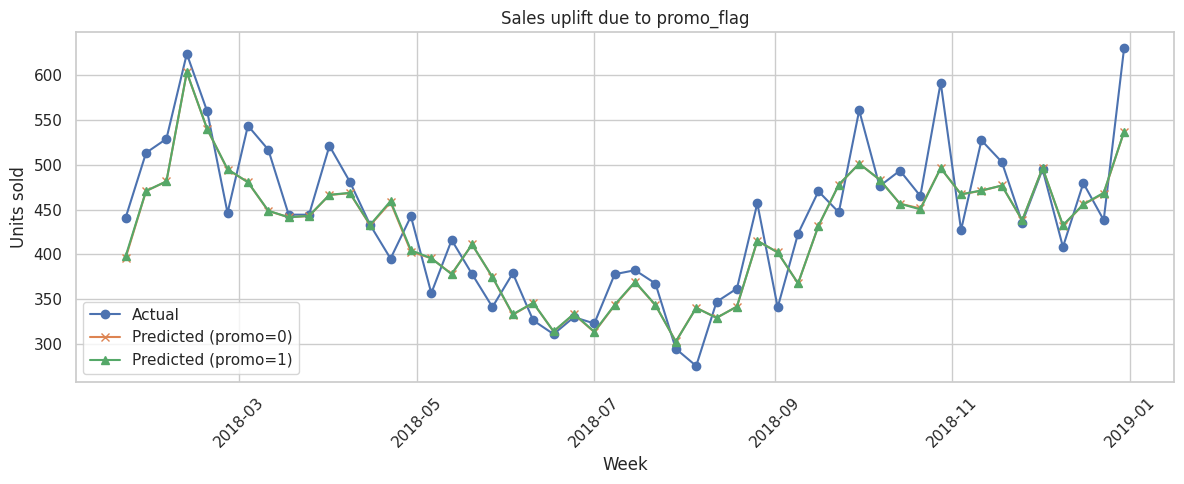

In [14]:
# ----------------- Promotional Impact Modeling (Enhanced with Synthetic Promo) -----------------
import numpy as np

# Detect promo column
promo_candidates = [c for c in CLEANED_DF.columns if 'promo' in c.lower() or 'discount' in c.lower()]

# If none exists, create a synthetic promo column
if not promo_candidates:
    np.random.seed(42)
    CLEANED_DF['promo_flag'] = np.random.choice([0,1], size=len(CLEANED_DF), p=[0.8, 0.2])
    promo_col = 'promo_flag'
    print("No promo column detected. Created synthetic promo column:", promo_col)
else:
    promo_col = promo_candidates[0]
    print("Using promo column:", promo_col)

# Weekly aggregation
weekly = CLEANED_DF[[promo_col]+SALES_COLS].resample('W').agg({promo_col:'max', **{c:'sum' for c in SALES_COLS}})

# Compute total sales
weekly['total'] = weekly[SALES_COLS].sum(axis=1)

# Feature creation
weekly_feat = make_time_features(weekly['total']).dropna()
weekly_feat['promo'] = weekly[promo_col].reindex(weekly_feat.index).fillna(0)

# Train/test split
X = weekly_feat.drop(columns=['y'])
y = weekly_feat['y']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)

# Fit model
model_promo = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, random_state=42)
model_promo.fit(X_tr, y_tr)

# Estimate uplift
X_te_cf = X_te.copy()
X_te_cf['promo'] = 1  # Counterfactual: promo applied
lift = (model_promo.predict(X_te_cf) - model_promo.predict(X_te)).mean()
print(f'\nEstimated weekly uplift when promo=1: {lift:.2f} units')

# Feature importance
importances = pd.Series(model_promo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances (top 10):")
display(importances.head(10))

# Visualization: actual vs predicted with/without promo
y_pred_actual = model_promo.predict(X_te)
y_pred_promo = model_promo.predict(X_te_cf)
plt.figure(figsize=(12,5))
plt.plot(y_te.index, y_te.values, label='Actual', marker='o')
plt.plot(y_te.index, y_pred_actual, label='Predicted (promo=0)', marker='x')
plt.plot(y_te.index, y_pred_promo, label='Predicted (promo=1)', marker='^')
plt.title(f'Sales uplift due to {promo_col}')
plt.xlabel('Week')
plt.ylabel('Units sold')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# ----------------- Category Sales Risk Classification -----------------
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Use latest YoY pct change
risk_df = latest_pct_yoy.copy()
risk_df['label'] = pd.cut(
    risk_df['pct_yoy'],
    bins=[-np.inf, -0.2, 0.2, np.inf],
    labels=['decline','stable','spike']
)

# Reset index and rename column
risk_df = risk_df.reset_index().rename(columns={'index':'category'})

# Save CSV
risk_df.to_csv('/content/atc_risk_labels.csv', index=False)
print('Saved /content/atc_risk_labels.csv')

# Display labeled DataFrame
display(risk_df)

# ----------------- Optional: Train a simple classifier -----------------
# Use lag features from CLEANED_DF to predict risk
# Only proceed if we have enough categories
if len(SALES_COLS) >= 3:
    features_list = []
    labels_list = []

    for cat in SALES_COLS:
        if cat in risk_df['category'].values:
            series = CLEANED_DF[cat].resample('W').sum()
            feats = make_time_features(series).dropna()
            X = feats[numeric_feature_template]
            y = [risk_df.loc[risk_df['category']==cat,'label'].values[0]]*len(X)
            features_list.append(X)
            labels_list.extend(y)

    if features_list:
        X_all = pd.concat(features_list, axis=0)
        y_all = pd.Series(labels_list)

        X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)

        print("\nClassification Report:")
        print(classification_report(y_te, y_pred))
        print("Confusion Matrix:")
        print(confusion_matrix(y_te, y_pred))


Saved /content/atc_risk_labels.csv


,category,pct_yoy,label
0,M01AB,-9.525678,decline
1,M01AE,-1.603483,decline
2,N02BA,-35.265520,decline
3,N02BE,14.970682,spike
4,N05B,17.213115,spike
5,N05C,233.333333,spike
6,R03,62.231760,spike
7,R06,7.614213,spike



Classification Report:
              precision    recall  f1-score   support

     decline       0.92      0.99      0.95       150
       spike       0.99      0.95      0.97       250

    accuracy                           0.96       400
   macro avg       0.96      0.97      0.96       400
weighted avg       0.96      0.96      0.96       400

Confusion Matrix:
[[148   2]
 [ 13 237]]


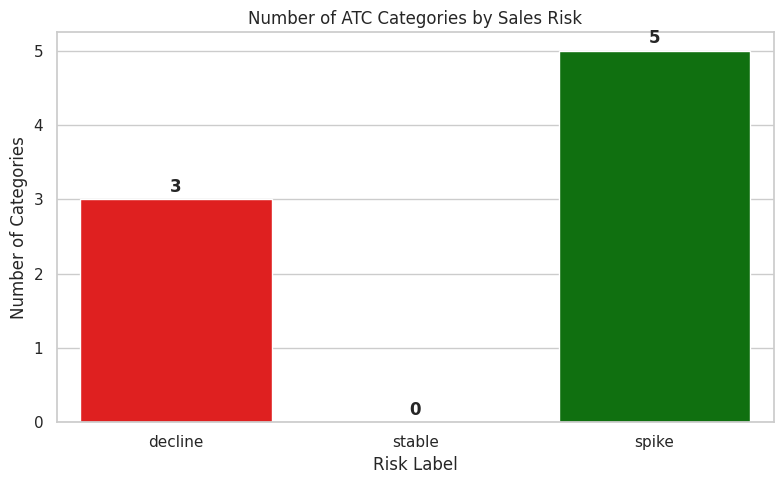

In [16]:
# ----------------- Visualize Category Sales Risk -----------------
import matplotlib.pyplot as plt
import seaborn as sns

# Count of categories per risk label
risk_counts = risk_df['label'].value_counts().reindex(['decline','stable','spike'])
plt.figure(figsize=(8,5))
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette=['red','gray','green'])
plt.title('Number of ATC Categories by Sales Risk')
plt.ylabel('Number of Categories')
plt.xlabel('Risk Label')
for i, v in enumerate(risk_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


Saved /content/category_clusters.csv


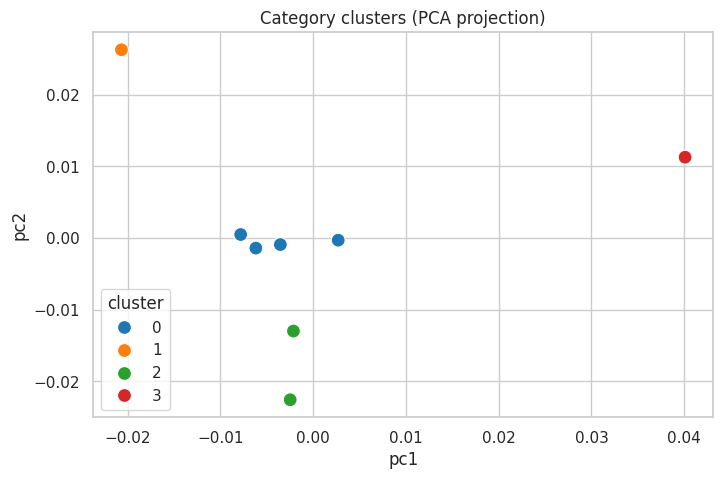

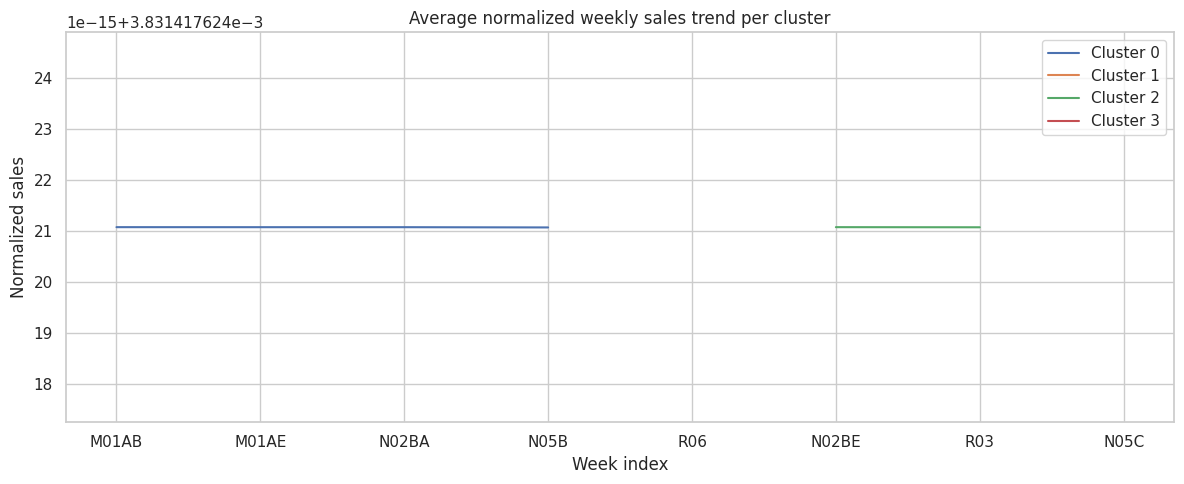

In [17]:
# --------------------- Enhanced Drug Segmentation (Phase 9) ---------------------
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Build matrix: rows=categories, cols=weekly time buckets
weekly_matrix = CLEANED_DF[SALES_COLS].resample('W').sum().T.fillna(0)

# Normalize rows (per-category)
row_sums = weekly_matrix.sum(axis=1).replace(0,1)
weekly_norm = weekly_matrix.div(row_sums, axis=0)

# ----------------- Determine number of clusters (optional: silhouette method) -----------------
k = min(4, len(weekly_norm))  # default k
# Optionally, use silhouette score to select k
# from sklearn.metrics import silhouette_score
# scores = []
# for n in range(2, min(10,len(weekly_norm))):
#     km_test = KMeans(n_clusters=n, random_state=42).fit(weekly_norm)
#     scores.append(silhouette_score(weekly_norm, km_test.labels_))
# plt.plot(range(2, len(scores)+2), scores, marker='o')
# plt.title("Silhouette Score for different k")
# plt.xlabel("Number of clusters")
# plt.ylabel("Silhouette Score")
# plt.show()

# ----------------- KMeans clustering -----------------
km = KMeans(n_clusters=k, random_state=42)
clusters = km.fit_predict(weekly_norm)

# ----------------- PCA for visualization -----------------
pca = PCA(n_components=2)
coords = pca.fit_transform(weekly_norm)
cluster_df = pd.DataFrame({
    'category': weekly_norm.index,
    'cluster': clusters,
    'pc1': coords[:,0],
    'pc2': coords[:,1]
})

# Save cluster assignments
cluster_df.to_csv('/content/category_clusters.csv', index=False)
print('Saved /content/category_clusters.csv')

# ----------------- PCA scatter plot -----------------
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=cluster_df, x='pc1', y='pc2', hue='cluster', palette='tab10', s=100, ax=ax)
ax.set_title('Category clusters (PCA projection)')
plt.show()

# ----------------- Cluster profiling: average normalized weekly trend -----------------
weekly_norm['cluster'] = clusters
plt.figure(figsize=(12,5))
for c in sorted(weekly_norm['cluster'].unique()):
    avg_trend = weekly_norm.loc[weekly_norm['cluster']==c].drop('cluster', axis=1).T.mean()
    plt.plot(avg_trend, label=f'Cluster {c}')
plt.title("Average normalized weekly sales trend per cluster")
plt.xlabel("Week index")
plt.ylabel("Normalized sales")
plt.legend()
plt.tight_layout()
plt.show()


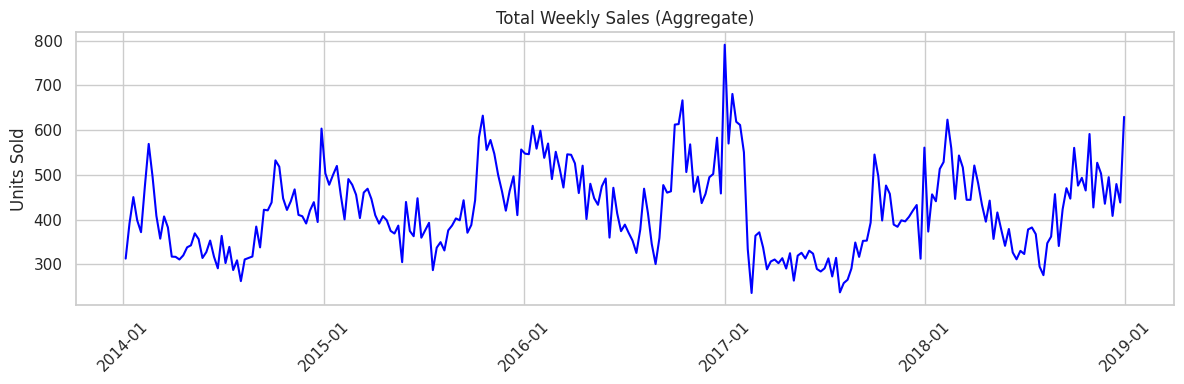

Saved /content/total_weekly_sales.png


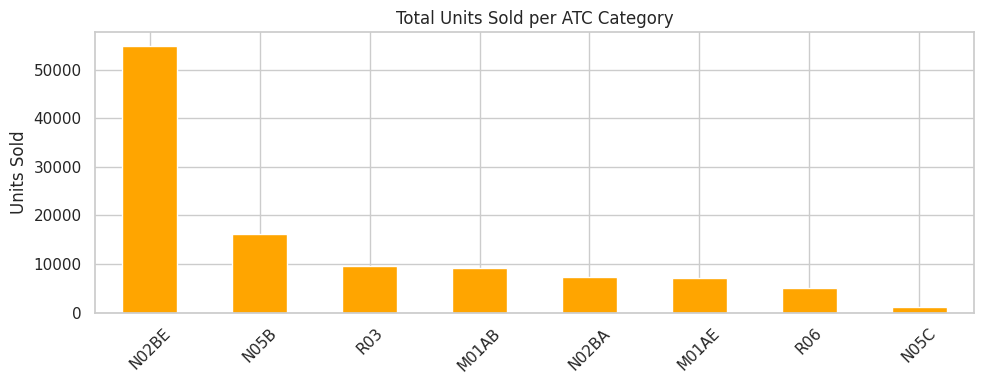

Saved /content/category_totals.csv


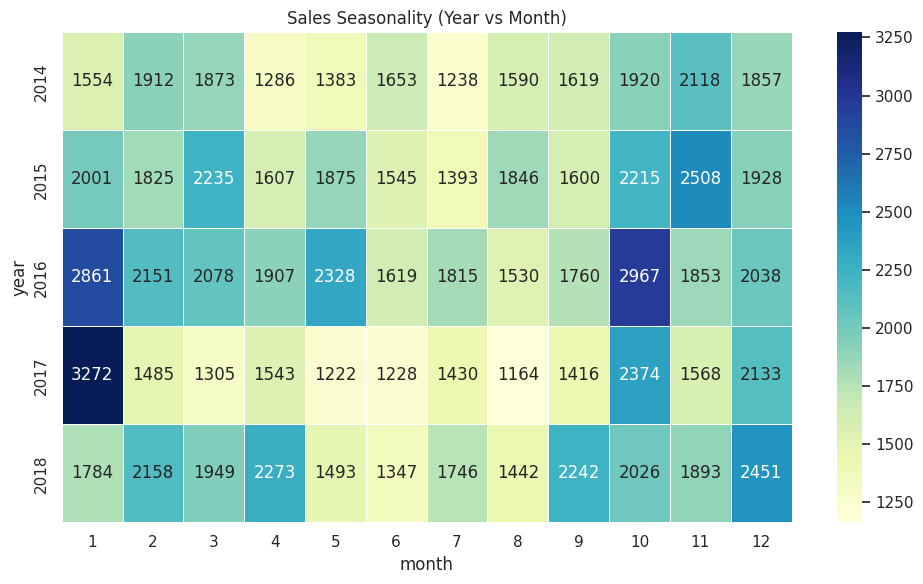

Saved /content/sales_seasonality_heatmap.png


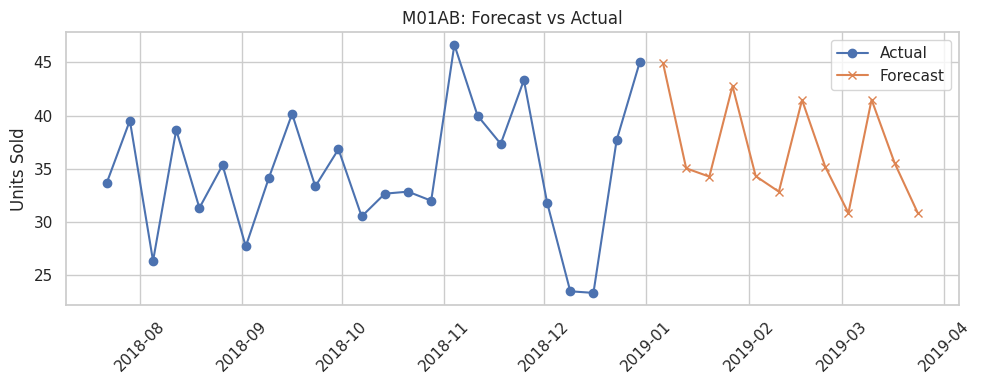

Saved /content/forecast_vs_actual_M01AB.png


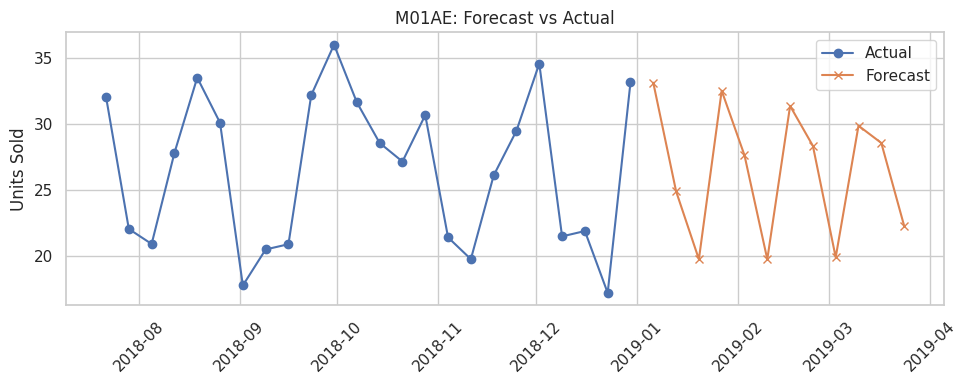

Saved /content/forecast_vs_actual_M01AE.png


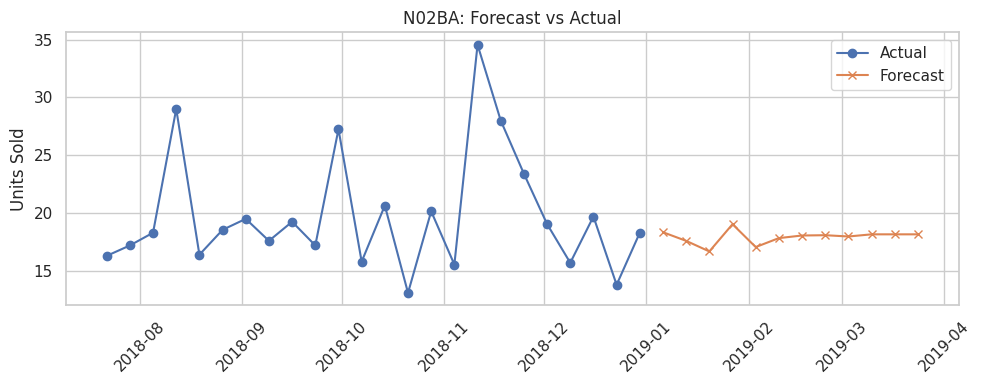

Saved /content/forecast_vs_actual_N02BA.png


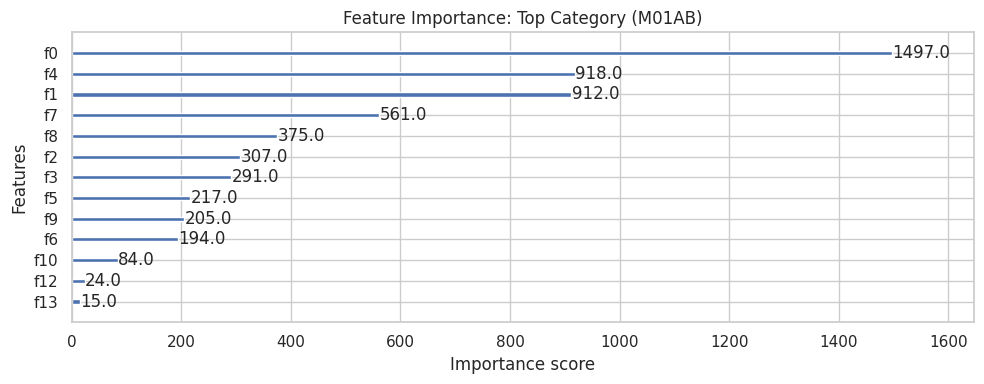

Saved /content/feature_importance_M01AB.png
Saved /content/category_forecasts_next12weeks.csv


In [18]:
# --------------------- Phase 10 — Visualization & Communication ---------------------
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Display and save total weekly sales
fig_total, ax = plt.subplots(figsize=(12,4))
ax.plot(total_series.index, total_series.values, color='blue')
ax.set_title('Total Weekly Sales (Aggregate)')
ax.set_ylabel('Units Sold')
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_fig(fig_total, '/content/total_weekly_sales.png')

# 2) Display and save category totals bar chart
fig_cat, ax = plt.subplots(figsize=(10,4))
cat_totals.sort_values(ascending=False).plot(kind='bar', ax=ax, color='orange')
ax.set_title('Total Units Sold per ATC Category')
ax.set_ylabel('Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
cat_totals.to_csv('/content/category_totals.csv')
print('Saved /content/category_totals.csv')

# 3) Display and save sales seasonality heatmap
sales_monthly = CLEANED_DF['total_sales'].resample('ME').sum().to_frame('sales')
sales_monthly['year'] = sales_monthly.index.year
sales_monthly['month'] = sales_monthly.index.month
pivot = sales_monthly.pivot_table(index='year', columns='month', values='sales', aggfunc='sum')

fig_heat, ax = plt.subplots(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', linewidths=.5, ax=ax, cmap='YlGnBu')
ax.set_title('Sales Seasonality (Year vs Month)')
plt.tight_layout()
plt.show()
save_fig(fig_heat, '/content/sales_seasonality_heatmap.png')

# 4) Display forecast vs actual per category (first 3 categories as example)
for cat in SALES_COLS[:3]:  # limit to 3 for readability
    fig, ax = plt.subplots(figsize=(10,4))
    actual = CLEANED_DF[cat].resample('W').sum()[-H*2:]  # last H*2 weeks for comparison
    forecast = forecasts_df[cat][:H]
    ax.plot(actual.index, actual.values, label='Actual', marker='o')
    ax.plot(forecast.index, forecast.values, label='Forecast', marker='x')
    ax.set_title(f'{cat}: Forecast vs Actual')
    ax.set_ylabel('Units Sold')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    save_fig(fig, f'/content/forecast_vs_actual_{cat}.png')

# 5) Feature importance from last trained XGBoost model (example: top category)
if 'model' in pipeline.named_steps:
    xgb_model = pipeline.named_steps['model']
    try:
        fig_imp, ax = plt.subplots(figsize=(10,4))
        xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=15, ax=ax)
        ax.set_title(f'Feature Importance: Top Category ({top_cat})')
        plt.tight_layout()
        plt.show()
        save_fig(fig_imp, f'/content/feature_importance_{top_cat}.png')
    except Exception as e:
        print("Could not plot feature importance:", e)

# 6) Save forecasts CSV
forecasts_df.to_csv('/content/category_forecasts_next12weeks.csv')
print('Saved /content/category_forecasts_next12weeks.csv')


In [19]:
# --------------------- Phase 11 — Executive Summary & Deliverables ---------------------
summary = f"""
# Executive Summary - Pharmacy Sales Forecasting

**Primary dataset**: {primary}
**Time span**: {CLEANED_DF.index.min().date()} to {CLEANED_DF.index.max().date()}
**Models built**: {len(results)} category models (saved under {models_dir})
**Forecast horizon**: {H} weeks

**Files produced**:
- /content/category_model_summary.csv
- /content/category_forecasts_next12weeks.csv
- /content/category_totals.csv
- /content/atc_risk_labels.csv (if available)
- /content/category_clusters.csv (if run)
"""

# Save markdown file
summary_path = '/content/executive_summary.md'
with open(summary_path,'w') as f:
    f.write(summary)
print(f'Saved {summary_path}')

# Display the summary in notebook
from IPython.display import Markdown, display
display(Markdown(summary))


Saved /content/executive_summary.md



# Executive Summary - Pharmacy Sales Forecasting

**Primary dataset**: weekly
**Time span**: 2014-01-05 to 2018-12-30
**Models built**: 8 category models (saved under /content/models_per_category)
**Forecast horizon**: 12 weeks

**Files produced**:
- /content/category_model_summary.csv
- /content/category_forecasts_next12weeks.csv
- /content/category_totals.csv
- /content/atc_risk_labels.csv (if available)
- /content/category_clusters.csv (if run)
